
# PanTiny — Six-Band Full Training (50 Epochs)

هذه Notebook مستقلة لتجربة **PanTiny مكيّفة إلى 6 Bands** على نفس Local Wald split المستخدم في المشروع:

```text
Train      = 231 patches
Validation = 22 patches
Test       = 22 patches
```

## المهمة

```text
LR-MS: 6 × 64 × 64
+
HR-PAN: 1 × 256 × 256
↓
PanTiny 6-Band
↓
HR-MS: 6 × 256 × 256
```

## ما الذي يطابق فكرة PanTiny المنشورة؟

- Lightweight single-step pansharpening.
- Single lightweight MS encoder.
- Simple PAN fusion بدل fusion معقدة.
- Transformer body يعتمد على Channel Attention وGDFN.
- Enhanced convolution refinement.
- Residual reconstruction فوق Bicubic MS.
- Composite loss:
  - Charbonnier
  - SSIM
  - Focal regression

## تنبيه علمي

هذه **Six-Band Local Adaptation** مبنية على التصميم المنشور، وليست إعادة إنتاج كاملة لتجربة `multiple-in-one` الأصلية؛ لأن الداتا الحالية محلية ذات 6 Bands وليست مجموعة WV2 + WV3 + GF2 الكاملة.

الهدف الأول هنا هو مقارنة Architecture وLoss مع:

```text
Bicubic
Fusion CNN
WV3-Transfer HAT
Pan-Mamba
PanTiny 6-Band
```


## Full-training configuration

هذه النسخة مضبوطة مباشرة على:

```text
FAST_RUN = False
Epochs = 50
Train = 231 patches
Validation = 22 patches
Test = 22 patches
```

شغّلها من أول خلية في Runtime جديدة لضمان أن التدريب يبدأ من أوزان عشوائية نظيفة، وليس من Smoke Test سابق.



## 1. تفعيل GPU وتثبيت الاعتماديات

PanTiny لا تحتاج Mamba أوCUDA extensions خاصة. تعمل على PyTorch الموجودة في Colab.


In [1]:

# Use a Google Colab GPU runtime:
# Runtime → Change runtime type → T4 GPU

!pip install -q pytorch-msssim rasterio pandas matplotlib tqdm


In [2]:

import os
import json
import math
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from pytorch_msssim import ssim as windowed_ssim

warnings.filterwarnings("ignore")

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU غير مفعلة. اختار Runtime → Change runtime type → T4 GPU."
    )

device = torch.device("cuda")

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: Tesla T4



## 2. ربط Google Drive ومسارات المشروع


In [3]:

from google.colab import drive
drive.mount("/content/drive")

PROJECT = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

DATA_ROOT = PROJECT / "Wald_Data_GSD" / "Patches"

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

STATS_PATH = (
    PROJECT
    / "Fusion_Baseline_Results"
    / "train_normalization_stats.json"
)

RESULTS_DIR = (
    PROJECT
    / "PanTiny_6Band_Results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for name, path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR,
    "Normalization stats": STATS_PATH,
    "Results": RESULTS_DIR,
}.items():
    print(
        f"{name:24s}",
        "→",
        path.exists(),
        "→",
        path,
    )

required_paths = [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    STATS_PATH,
]

missing = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing project paths:\n"
        + "\n".join(missing)
    )


Mounted at /content/drive
Train                    → True → /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/train
Validation               → True → /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/val
Test                     → True → /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/test
Normalization stats      → True → /content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results/train_normalization_stats.json
Results                  → True → /content/drive/MyDrive/Super_Resolution_28-07-2026/PanTiny_6Band_Results



## 3. إعدادات التجربة

ابدأ بـ:

```python
FAST_RUN = True
```

بعد نجاح الـSmoke Test غيّرها إلى:

```python
FAST_RUN = False
```


In [4]:

SEED = 123
FAST_RUN = False


SCALE = 4
MS_BANDS = 6

# PanTiny adaptation sizes:
# "small" is the recommended first run.
MODEL_SIZE = "small"

MODEL_CONFIGS = {
    "small": {
        "dim": 24,
        "depth": 4,
        "heads": 3,
        "ffn_expansion": 2.0,
    },
    "big": {
        "dim": 32,
        "depth": 4,
        "heads": 4,
        "ffn_expansion": 2.0,
    },
}

MODEL_CONFIG = MODEL_CONFIGS[MODEL_SIZE]

TRAIN_HR_CROP = 128
TRAIN_LR_CROP = TRAIN_HR_CROP // SCALE

BATCH_SIZE = 4
NUM_WORKERS = 0

EPOCHS = 50
LEARNING_RATE = 5e-4
MIN_LEARNING_RATE = 1e-6

WEIGHT_DECAY = 0.0
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 35

USE_AMP = True

# Published composite-loss weights.
CHARBONNIER_WEIGHT = 1.5
SSIM_WEIGHT = 4.0
FOCAL_WEIGHT = 1.5

# The accessible paper text defines r1 as a focusing parameter
# but does not expose a fixed value in the shown methodology text.
FOCAL_GAMMA = 1.0
CHARBONNIER_EPS = 1e-6

# Options:
# "paper_composite"
# "charbonnier_only"
LOSS_MODE = "paper_composite"

if FAST_RUN:
    EPOCHS = 2
    BATCH_SIZE = 2
    EARLY_STOPPING_PATIENCE = 5

print({
    "FAST_RUN": FAST_RUN,
    "MODEL_SIZE": MODEL_SIZE,
    "MODEL_CONFIG": MODEL_CONFIG,
    "TRAIN_HR_CROP": TRAIN_HR_CROP,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "LOSS_MODE": LOSS_MODE,
})


{'FAST_RUN': False, 'MODEL_SIZE': 'small', 'MODEL_CONFIG': {'dim': 24, 'depth': 4, 'heads': 3, 'ffn_expansion': 2.0}, 'TRAIN_HR_CROP': 128, 'BATCH_SIZE': 4, 'EPOCHS': 50, 'LOSS_MODE': 'paper_composite'}


In [5]:

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True


seed_everything(SEED)



## 4. Normalization

يتم استخدام إحصائيات Training split فقط لمنع Data Leakage.


In [6]:

with open(
    STATS_PATH,
    "r",
    encoding="utf-8",
) as file:
    normalization_stats = json.load(file)

MS_LOW = np.asarray(
    [
        band_stats["p01"]
        for band_stats in normalization_stats["ms"]
    ],
    dtype=np.float32,
)[:, None, None]

MS_HIGH = np.asarray(
    [
        band_stats["p99"]
        for band_stats in normalization_stats["ms"]
    ],
    dtype=np.float32,
)[:, None, None]

PAN_LOW = np.float32(
    normalization_stats["pan"]["p01"]
)

PAN_HIGH = np.float32(
    normalization_stats["pan"]["p99"]
)

assert MS_LOW.shape[0] == MS_BANDS
assert MS_HIGH.shape[0] == MS_BANDS

print("MS bands:", MS_LOW.shape[0])
print("PAN p01/p99:", float(PAN_LOW), float(PAN_HIGH))


MS bands: 6
PAN p01/p99: 769.0 4325.0


In [7]:

def normalize_ms(array: np.ndarray) -> np.ndarray:
    return np.clip(
        (
            array.astype(np.float32)
            - MS_LOW
        )
        / np.maximum(
            MS_HIGH - MS_LOW,
            1e-6,
        ),
        0,
        1,
    )


def normalize_pan(array: np.ndarray) -> np.ndarray:
    return np.clip(
        (
            array.astype(np.float32)
            - PAN_LOW
        )
        / max(
            float(PAN_HIGH - PAN_LOW),
            1e-6,
        ),
        0,
        1,
    )


def denormalize_ms_tensor(
    tensor: torch.Tensor,
) -> torch.Tensor:
    low = torch.as_tensor(
        MS_LOW,
        device=tensor.device,
        dtype=tensor.dtype,
    ).unsqueeze(0)

    high = torch.as_tensor(
        MS_HIGH,
        device=tensor.device,
        dtype=tensor.dtype,
    ).unsqueeze(0)

    return tensor * (high - low) + low



## 5. Dataset

كل NPZ متوقع أن يحتوي:

```text
lr_ms      → 6 × 64 × 64
pan        → 1 × 256 × 256
target_ms  → 6 × 256 × 256
```


In [8]:

def aligned_random_crop(
    lr_ms: np.ndarray,
    pan: np.ndarray,
    target: np.ndarray,
    hr_crop: int,
    scale: int,
):
    _, hr_height, hr_width = target.shape
    lr_crop = hr_crop // scale

    max_lr_y = (
        hr_height // scale
        - lr_crop
    )

    max_lr_x = (
        hr_width // scale
        - lr_crop
    )

    lr_y = random.randint(
        0,
        max_lr_y,
    )

    lr_x = random.randint(
        0,
        max_lr_x,
    )

    hr_y = lr_y * scale
    hr_x = lr_x * scale

    return (
        lr_ms[
            :,
            lr_y:lr_y + lr_crop,
            lr_x:lr_x + lr_crop,
        ],
        pan[
            :,
            hr_y:hr_y + hr_crop,
            hr_x:hr_x + hr_crop,
        ],
        target[
            :,
            hr_y:hr_y + hr_crop,
            hr_x:hr_x + hr_crop,
        ],
    )


def augment_triplet(
    lr_ms: np.ndarray,
    pan: np.ndarray,
    target: np.ndarray,
):
    if random.random() < 0.5:
        lr_ms = lr_ms[:, :, ::-1]
        pan = pan[:, :, ::-1]
        target = target[:, :, ::-1]

    if random.random() < 0.5:
        lr_ms = lr_ms[:, ::-1, :]
        pan = pan[:, ::-1, :]
        target = target[:, ::-1, :]

    rotations = random.randint(0, 3)

    if rotations:
        lr_ms = np.rot90(
            lr_ms,
            rotations,
            axes=(1, 2),
        )

        pan = np.rot90(
            pan,
            rotations,
            axes=(1, 2),
        )

        target = np.rot90(
            target,
            rotations,
            axes=(1, 2),
        )

    return (
        np.ascontiguousarray(lr_ms),
        np.ascontiguousarray(pan),
        np.ascontiguousarray(target),
    )


class WaldNPZDataset(Dataset):
    def __init__(
        self,
        folder: Path,
        mode: str,
        hr_crop: int | None = None,
    ):
        self.folder = Path(folder)
        self.mode = mode
        self.hr_crop = hr_crop
        self.files = sorted(
            self.folder.glob("*.npz")
        )

        if not self.files:
            raise RuntimeError(
                f"No NPZ files found in {self.folder}"
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(
        self,
        index: int,
    ):
        path = self.files[index]

        with np.load(path) as sample:
            lr_ms = sample["lr_ms"].copy()
            pan = sample["pan"].copy()
            target = sample["target_ms"].copy()

        if pan.ndim == 2:
            pan = pan[None]

        if self.mode == "train" and self.hr_crop is not None:
            lr_ms, pan, target = aligned_random_crop(
                lr_ms,
                pan,
                target,
                self.hr_crop,
                SCALE,
            )

            lr_ms, pan, target = augment_triplet(
                lr_ms,
                pan,
                target,
            )

        return {
            "lr_ms": torch.from_numpy(
                normalize_ms(lr_ms)
            ).float(),

            "pan": torch.from_numpy(
                normalize_pan(pan)
            ).float(),

            "target": torch.from_numpy(
                normalize_ms(target)
            ).float(),

            "file": path.name,
            "index": int(index),
        }


train_dataset = WaldNPZDataset(
    TRAIN_DIR,
    mode="train",
    hr_crop=TRAIN_HR_CROP,
)

val_dataset = WaldNPZDataset(
    VAL_DIR,
    mode="val",
    hr_crop=None,
)

test_dataset = WaldNPZDataset(
    TEST_DIR,
    mode="test",
    hr_crop=None,
)

if FAST_RUN:
    train_dataset.files = train_dataset.files[:12]
    val_dataset.files = val_dataset.files[:4]
    test_dataset.files = test_dataset.files[:2]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(
    "Train / Val / Test:",
    len(train_dataset),
    len(val_dataset),
    len(test_dataset),
)

example = train_dataset[0]

for key in ["lr_ms", "pan", "target"]:
    print(
        key,
        tuple(example[key].shape),
        example[key].dtype,
    )


Train / Val / Test: 231 22 22
lr_ms (6, 32, 32) torch.float32
pan (1, 128, 128) torch.float32
target (6, 128, 128) torch.float32



# 6. PanTiny 6-Band Architecture

المسار:

```text
LR-MS
↓ Bicubic ×4
Single MS Encoder
+
Simple PAN Projection
↓
Simple Feature Fusion
↓
Channel-Attention Transformer Body
↓
Enhanced Conv: 3×3 + 3×3
↓
6-Band Residual
↓
Final = Bicubic MS + Residual
```


In [9]:

class LayerNorm2d(nn.Module):
    def __init__(
        self,
        channels: int,
    ):
        super().__init__()

        self.weight = nn.Parameter(
            torch.ones(channels)
        )

        self.bias = nn.Parameter(
            torch.zeros(channels)
        )

    def forward(
        self,
        tensor: torch.Tensor,
    ) -> torch.Tensor:
        mean = tensor.mean(
            dim=1,
            keepdim=True,
        )

        variance = tensor.var(
            dim=1,
            keepdim=True,
            unbiased=False,
        )

        normalized = (
            tensor - mean
        ) / torch.sqrt(
            variance + 1e-5
        )

        return (
            normalized
            * self.weight[
                None,
                :,
                None,
                None,
            ]
            + self.bias[
                None,
                :,
                None,
                None,
            ]
        )


class ChannelAttention(nn.Module):
    def __init__(
        self,
        dim: int,
        heads: int,
    ):
        super().__init__()

        if dim % heads != 0:
            raise ValueError(
                "dim must be divisible by heads"
            )

        self.dim = dim
        self.heads = heads

        self.temperature = nn.Parameter(
            torch.ones(
                heads,
                1,
                1,
            )
        )

        self.qkv = nn.Conv2d(
            dim,
            dim * 3,
            kernel_size=1,
            bias=False,
        )

        self.qkv_dwconv = nn.Conv2d(
            dim * 3,
            dim * 3,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=dim * 3,
            bias=False,
        )

        self.project_out = nn.Conv2d(
            dim,
            dim,
            kernel_size=1,
            bias=False,
        )

    def forward(
        self,
        tensor: torch.Tensor,
    ) -> torch.Tensor:
        batch, channels, height, width = tensor.shape

        qkv = self.qkv_dwconv(
            self.qkv(tensor)
        )

        query, key, value = qkv.chunk(
            3,
            dim=1,
        )

        channels_per_head = (
            channels // self.heads
        )

        query = query.reshape(
            batch,
            self.heads,
            channels_per_head,
            height * width,
        )

        key = key.reshape(
            batch,
            self.heads,
            channels_per_head,
            height * width,
        )

        value = value.reshape(
            batch,
            self.heads,
            channels_per_head,
            height * width,
        )

        query = F.normalize(
            query,
            dim=-1,
        )

        key = F.normalize(
            key,
            dim=-1,
        )

        attention = (
            query
            @ key.transpose(-2, -1)
        ) * self.temperature

        attention = attention.softmax(
            dim=-1
        )

        output = attention @ value

        output = output.reshape(
            batch,
            channels,
            height,
            width,
        )

        return self.project_out(
            output
        )


class GatedDConvFeedForward(nn.Module):
    def __init__(
        self,
        dim: int,
        expansion: float,
    ):
        super().__init__()

        hidden = int(
            dim * expansion
        )

        self.project_in = nn.Conv2d(
            dim,
            hidden * 2,
            kernel_size=1,
            bias=False,
        )

        self.depthwise = nn.Conv2d(
            hidden * 2,
            hidden * 2,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=hidden * 2,
            bias=False,
        )

        self.project_out = nn.Conv2d(
            hidden,
            dim,
            kernel_size=1,
            bias=False,
        )

    def forward(
        self,
        tensor: torch.Tensor,
    ) -> torch.Tensor:
        tensor = self.depthwise(
            self.project_in(tensor)
        )

        first, second = tensor.chunk(
            2,
            dim=1,
        )

        tensor = (
            F.gelu(first)
            * second
        )

        return self.project_out(
            tensor
        )


class TransformerBlock(nn.Module):
    def __init__(
        self,
        dim: int,
        heads: int,
        expansion: float,
    ):
        super().__init__()

        self.norm1 = LayerNorm2d(dim)
        self.attention = ChannelAttention(
            dim,
            heads,
        )

        self.norm2 = LayerNorm2d(dim)
        self.ffn = GatedDConvFeedForward(
            dim,
            expansion,
        )

    def forward(
        self,
        tensor: torch.Tensor,
    ) -> torch.Tensor:
        tensor = (
            tensor
            + self.attention(
                self.norm1(tensor)
            )
        )

        tensor = (
            tensor
            + self.ffn(
                self.norm2(tensor)
            )
        )

        return tensor


class EnhancedConv(nn.Module):
    def __init__(
        self,
        dim: int,
    ):
        super().__init__()

        self.body = nn.Sequential(
            nn.Conv2d(
                dim,
                dim,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GELU(),
            nn.Conv2d(
                dim,
                dim,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
        )

    def forward(
        self,
        tensor: torch.Tensor,
    ) -> torch.Tensor:
        return (
            tensor
            + self.body(tensor)
        )


class PanTiny6Band(nn.Module):
    def __init__(
        self,
        ms_bands: int,
        dim: int,
        depth: int,
        heads: int,
        ffn_expansion: float,
    ):
        super().__init__()

        self.ms_encoder = nn.Sequential(
            nn.Conv2d(
                ms_bands,
                dim,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GELU(),
        )

        # Simple PAN integration: one lightweight projection only.
        self.pan_projection = nn.Conv2d(
            1,
            dim,
            kernel_size=3,
            padding=1,
            bias=False,
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(
                dim * 2,
                dim,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GELU(),
        )

        self.body = nn.Sequential(
            *[
                TransformerBlock(
                    dim=dim,
                    heads=heads,
                    expansion=ffn_expansion,
                )
                for _ in range(depth)
            ]
        )

        self.enhanced_conv = EnhancedConv(dim)

        self.output = nn.Conv2d(
            dim,
            ms_bands,
            kernel_size=3,
            padding=1,
            bias=True,
        )

    def forward(
        self,
        lr_ms: torch.Tensor,
        pan: torch.Tensor,
    ) -> torch.Tensor:
        ms_bicubic = F.interpolate(
            lr_ms,
            size=pan.shape[-2:],
            mode="bicubic",
            align_corners=False,
        )

        ms_features = self.ms_encoder(
            ms_bicubic
        )

        pan_features = self.pan_projection(
            pan
        )

        fused = self.fusion(
            torch.cat(
                [
                    ms_features,
                    pan_features,
                ],
                dim=1,
            )
        )

        body_features = (
            fused
            + self.body(fused)
        )

        refined = self.enhanced_conv(
            body_features
        )

        residual = self.output(
            refined
        )

        return (
            ms_bicubic
            + residual
        ).clamp(
            0,
            1,
        )


model = PanTiny6Band(
    ms_bands=MS_BANDS,
    dim=MODEL_CONFIG["dim"],
    depth=MODEL_CONFIG["depth"],
    heads=MODEL_CONFIG["heads"],
    ffn_expansion=MODEL_CONFIG[
        "ffn_expansion"
    ],
).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Model size:",
    MODEL_SIZE,
)

print(
    "Parameters:",
    f"{parameter_count:,}",
    f"({parameter_count / 1000:.1f} K)",
)


Model size: small
Parameters: 53,034 (53.0 K)



## 7. Forward Test

لا تبدأ التدريب قبل نجاح هذه الخلية.


In [10]:

model.eval()

with torch.inference_mode():
    sample_lr = (
        example["lr_ms"]
        .unsqueeze(0)
        .to(device)
    )

    sample_pan = (
        example["pan"]
        .unsqueeze(0)
        .to(device)
    )

    sample_output = model(
        sample_lr,
        sample_pan,
    )

print("LR-MS:", tuple(sample_lr.shape))
print("PAN:", tuple(sample_pan.shape))
print("Output:", tuple(sample_output.shape))

assert sample_output.shape == (
    1,
    MS_BANDS,
    TRAIN_HR_CROP,
    TRAIN_HR_CROP,
)

print("FORWARD TEST: PASSED")


LR-MS: (1, 6, 32, 32)
PAN: (1, 1, 128, 128)
Output: (1, 6, 128, 128)
FORWARD TEST: PASSED



# 8. Composite Loss

الـLoss المنشورة:

```text
L_total =
1.5 × Charbonnier
+
4.0 × SSIM Loss
+
1.5 × Focal Regression
```


In [11]:

class CharbonnierLoss(nn.Module):
    def __init__(
        self,
        epsilon: float = 1e-6,
    ):
        super().__init__()
        self.epsilon = epsilon

    def forward(
        self,
        prediction: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        difference = (
            prediction - target
        )

        return torch.mean(
            torch.sqrt(
                difference ** 2
                + self.epsilon ** 2
            )
        )


class FocalRegressionLoss(nn.Module):
    def __init__(
        self,
        gamma: float = 1.0,
    ):
        super().__init__()
        self.gamma = gamma

    def forward(
        self,
        prediction: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        absolute_error = torch.abs(
            prediction - target
        )

        weight = (
            255.0 * absolute_error
        ).pow(
            self.gamma
        ) / 255.0

        return torch.mean(
            weight * absolute_error
        )


charbonnier_loss = CharbonnierLoss(
    CHARBONNIER_EPS
)

focal_loss = FocalRegressionLoss(
    FOCAL_GAMMA
)


def compute_training_loss(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    charbonnier = charbonnier_loss(
        prediction,
        target,
    )

    ssim_loss_value = (
        1.0
        - windowed_ssim(
            prediction.float(),
            target.float(),
            data_range=1.0,
            size_average=True,
        )
    )

    focal = focal_loss(
        prediction,
        target,
    )

    if LOSS_MODE == "charbonnier_only":
        total = charbonnier

    elif LOSS_MODE == "paper_composite":
        total = (
            CHARBONNIER_WEIGHT
            * charbonnier
            + SSIM_WEIGHT
            * ssim_loss_value
            + FOCAL_WEIGHT
            * focal
        )

    else:
        raise ValueError(
            f"Unknown LOSS_MODE: {LOSS_MODE}"
        )

    components = {
        "total": total,
        "charbonnier": charbonnier,
        "ssim_loss": ssim_loss_value,
        "focal": focal,
    }

    return total, components



# 9. Metrics

يتم حساب:

- PSNR
- Global SSIM
- Windowed SSIM
- SAM
- ERGAS
- L1


In [12]:

def psnr_per_image(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    mse = torch.mean(
        (
            prediction - target
        ) ** 2,
        dim=(1, 2, 3),
    )

    return 10.0 * torch.log10(
        1.0
        / torch.clamp(
            mse,
            min=1e-12,
        )
    )


def global_ssim_per_image(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    spatial_dims = (2, 3)

    mu_x = prediction.mean(
        dim=spatial_dims,
        keepdim=True,
    )

    mu_y = target.mean(
        dim=spatial_dims,
        keepdim=True,
    )

    variance_x = (
        (
            prediction - mu_x
        ) ** 2
    ).mean(
        dim=spatial_dims,
        keepdim=True,
    )

    variance_y = (
        (
            target - mu_y
        ) ** 2
    ).mean(
        dim=spatial_dims,
        keepdim=True,
    )

    covariance = (
        (
            prediction - mu_x
        )
        * (
            target - mu_y
        )
    ).mean(
        dim=spatial_dims,
        keepdim=True,
    )

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    numerator = (
        (
            2 * mu_x * mu_y
            + c1
        )
        * (
            2 * covariance
            + c2
        )
    )

    denominator = (
        (
            mu_x ** 2
            + mu_y ** 2
            + c1
        )
        * (
            variance_x
            + variance_y
            + c2
        )
    )

    band_ssim = numerator / torch.clamp(
        denominator,
        min=1e-12,
    )

    return band_ssim.mean(
        dim=(1, 2, 3)
    )


def windowed_ssim_per_image(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    values = windowed_ssim(
        prediction.float(),
        target.float(),
        data_range=1.0,
        size_average=False,
    )

    if values.ndim == 0:
        values = values.unsqueeze(0)

    return values


def sam_per_image(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    prediction_dn = denormalize_ms_tensor(
        prediction
    )

    target_dn = denormalize_ms_tensor(
        target
    )

    dot = torch.sum(
        prediction_dn * target_dn,
        dim=1,
    )

    denominator = torch.clamp(
        torch.linalg.vector_norm(
            prediction_dn,
            dim=1,
        )
        * torch.linalg.vector_norm(
            target_dn,
            dim=1,
        ),
        min=1e-8,
    )

    cosine = torch.clamp(
        dot / denominator,
        -1 + 1e-7,
        1 - 1e-7,
    )

    angle = (
        torch.acos(cosine)
        * 180.0
        / math.pi
    )

    return angle.mean(
        dim=(1, 2)
    )


def ergas_per_image(
    prediction: torch.Tensor,
    target: torch.Tensor,
    ratio: int = 4,
):
    prediction_dn = denormalize_ms_tensor(
        prediction
    )

    target_dn = denormalize_ms_tensor(
        target
    )

    rmse = torch.sqrt(
        torch.mean(
            (
                prediction_dn
                - target_dn
            ) ** 2,
            dim=(2, 3),
        )
    )

    target_mean = torch.mean(
        target_dn,
        dim=(2, 3),
    ).abs().clamp_min(
        1e-6
    )

    return (
        100.0
        / float(ratio)
        * torch.sqrt(
            torch.mean(
                (
                    rmse
                    / target_mean
                ) ** 2,
                dim=1,
            )
        )
    )


def l1_per_image(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    return torch.mean(
        torch.abs(
            prediction - target
        ),
        dim=(1, 2, 3),
    )


def metric_dictionary(
    prediction: torch.Tensor,
    target: torch.Tensor,
):
    return {
        "PSNR": psnr_per_image(
            prediction,
            target,
        ),
        "SSIM_global": global_ssim_per_image(
            prediction,
            target,
        ),
        "SSIM_windowed": windowed_ssim_per_image(
            prediction,
            target,
        ),
        "SAM": sam_per_image(
            prediction,
            target,
        ),
        "ERGAS": ergas_per_image(
            prediction,
            target,
            ratio=SCALE,
        ),
        "L1": l1_per_image(
            prediction,
            target,
        ),
    }



# 10. Validation and Training


In [13]:

@torch.inference_mode()
def validate(
    model: nn.Module,
    loader: DataLoader,
):
    model.eval()

    losses = []
    psnr_values = []

    for batch in loader:
        lr_ms = batch["lr_ms"].to(
            device,
            non_blocking=True,
        )

        pan = batch["pan"].to(
            device,
            non_blocking=True,
        )

        target = batch["target"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(
                lr_ms,
                pan,
            )

        loss, _ = compute_training_loss(
            prediction.float(),
            target.float(),
        )

        losses.append(
            float(loss.cpu())
        )

        psnr_values.extend(
            psnr_per_image(
                prediction.float(),
                target.float(),
            ).cpu().tolist()
        )

    return {
        "loss": float(
            np.mean(losses)
        ),
        "psnr": float(
            np.mean(psnr_values)
        ),
    }


In [14]:

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(EPOCHS, 1),
    eta_min=MIN_LEARNING_RATE,
)

scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP,
)

history_rows = []

best_val_psnr = -float("inf")
best_epoch = None
epochs_without_improvement = 0

BEST_CHECKPOINT = (
    RESULTS_DIR
    / f"best_pantiny_{MODEL_SIZE}_6band.pth"
)

LATEST_CHECKPOINT = (
    RESULTS_DIR
    / f"latest_pantiny_{MODEL_SIZE}_6band.pth"
)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_total = 0.0
    running_charbonnier = 0.0
    running_ssim = 0.0
    running_focal = 0.0
    processed_batches = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS}",
        leave=False,
    )

    for batch in progress:
        lr_ms = batch["lr_ms"].to(
            device,
            non_blocking=True,
        )

        pan = batch["pan"].to(
            device,
            non_blocking=True,
        )

        target = batch["target"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(
                lr_ms,
                pan,
            )

        total_loss, components = (
            compute_training_loss(
                prediction.float(),
                target.float(),
            )
        )

        scaler.scale(
            total_loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        running_total += float(
            components["total"].detach().cpu()
        )

        running_charbonnier += float(
            components[
                "charbonnier"
            ].detach().cpu()
        )

        running_ssim += float(
            components[
                "ssim_loss"
            ].detach().cpu()
        )

        running_focal += float(
            components[
                "focal"
            ].detach().cpu()
        )

        processed_batches += 1

        progress.set_postfix(
            loss=(
                running_total
                / processed_batches
            )
        )

    validation = validate(
        model,
        val_loader,
    )

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_total": (
            running_total
            / processed_batches
        ),
        "train_charbonnier": (
            running_charbonnier
            / processed_batches
        ),
        "train_ssim_loss": (
            running_ssim
            / processed_batches
        ),
        "train_focal": (
            running_focal
            / processed_batches
        ),
        "val_loss": validation["loss"],
        "val_psnr": validation["psnr"],
        "lr": optimizer.param_groups[0]["lr"],
    }

    history_rows.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"Train {row['train_total']:.6f} | "
        f"Val {row['val_loss']:.6f} | "
        f"PSNR {row['val_psnr']:.4f} dB"
    )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "history": history_rows,
        "model_size": MODEL_SIZE,
        "model_config": MODEL_CONFIG,
        "loss_mode": LOSS_MODE,
        "parameter_count": parameter_count,
    }

    torch.save(
        checkpoint,
        LATEST_CHECKPOINT,
    )

    if row["val_psnr"] > best_val_psnr:
        best_val_psnr = row["val_psnr"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            checkpoint,
            BEST_CHECKPOINT,
        )

        print("  Saved new best checkpoint.")

    else:
        epochs_without_improvement += 1

    if (
        not FAST_RUN
        and epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "Early stopping triggered."
        )
        break

training_seconds = time.time() - start_time

history_df = pd.DataFrame(
    history_rows
)

history_df.to_csv(
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_training_history.csv",
    index=False,
)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation PSNR:",
    best_val_psnr,
)

print(
    "Training time:",
    f"{training_seconds / 60:.2f} minutes",
)


Epoch 1/50:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 001 | Train 0.936008 | Val 0.526595 | PSNR 24.6492 dB
  Saved new best checkpoint.


Epoch 2/50:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 002 | Train 0.493946 | Val 0.473986 | PSNR 25.0468 dB
  Saved new best checkpoint.


Epoch 3/50:   0%|          | 0/58 [00:00<?, ?it/s]

...

Epoch 048 | Train 0.379713 | Val 0.405268 | PSNR 26.1584 dB


Epoch 49/50:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 049 | Train 0.381836 | Val 0.405529 | PSNR 26.1499 dB


Epoch 50/50:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 050 | Train 0.384238 | Val 0.405557 | PSNR 26.1490 dB
Best epoch: 42
Best validation PSNR: 26.163019353693183
Training time: 7.35 minutes


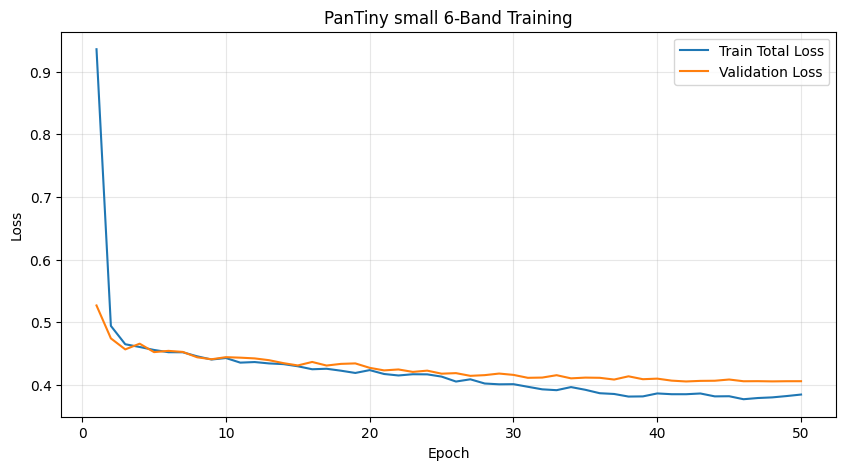

In [15]:

figure = plt.figure(
    figsize=(10, 5)
)

axis = figure.add_subplot(111)

axis.plot(
    history_df["epoch"],
    history_df["train_total"],
    label="Train Total Loss",
)

axis.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

axis.set_xlabel("Epoch")
axis.set_ylabel("Loss")
axis.set_title(
    f"PanTiny {MODEL_SIZE} 6-Band Training"
)

axis.grid(
    True,
    alpha=0.3,
)

axis.legend()

figure.savefig(
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_training_curve.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)



# 11. Load Best Checkpoint


In [16]:

if not BEST_CHECKPOINT.exists():
    raise FileNotFoundError(
        BEST_CHECKPOINT
    )

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

model.eval()

print(
    "Loaded best checkpoint from epoch:",
    best_checkpoint["epoch"],
)


Loaded best checkpoint from epoch: 42



# 12. Final Test Evaluation


In [17]:

test_rows = []

prediction_cache_dir = (
    RESULTS_DIR
    / f"test_predictions_{MODEL_SIZE}"
)

prediction_cache_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for sample_index in tqdm(
    range(len(test_dataset)),
    desc="Testing PanTiny",
):
    sample = test_dataset[
        sample_index
    ]

    lr_ms = sample["lr_ms"][
        None
    ].to(device)

    pan = sample["pan"][
        None
    ].to(device)

    target = sample["target"][
        None
    ].to(device)

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(
                lr_ms,
                pan,
            )

    prediction = prediction.float()

    bicubic = F.interpolate(
        lr_ms,
        size=target.shape[-2:],
        mode="bicubic",
        align_corners=False,
    ).clamp(
        0,
        1,
    )

    pantiny_metrics = metric_dictionary(
        prediction,
        target,
    )

    bicubic_metrics = metric_dictionary(
        bicubic,
        target,
    )

    row = {
        "index": sample_index,
        "file": sample["file"],
    }

    for metric_name, values in (
        pantiny_metrics.items()
    ):
        row[
            f"PanTiny_{metric_name}"
        ] = float(
            values[0].cpu()
        )

    for metric_name, values in (
        bicubic_metrics.items()
    ):
        row[
            f"Bicubic_{metric_name}"
        ] = float(
            values[0].cpu()
        )

    test_rows.append(row)

    np.savez_compressed(
        prediction_cache_dir
        / f"{Path(sample['file']).stem}.npz",
        prediction=prediction[
            0
        ].cpu().numpy(),
        bicubic=bicubic[
            0
        ].cpu().numpy(),
        target=target[
            0
        ].cpu().numpy(),
        pan=pan[
            0
        ].cpu().numpy(),
    )

test_df = pd.DataFrame(
    test_rows
)

test_df.to_csv(
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_local_test_per_image.csv",
    index=False,
)

display(
    test_df.round(6)
)


Testing PanTiny:   0%|          | 0/22 [00:00<?, ?it/s]

,index,file,PanTiny_PSNR,PanTiny_SSIM_global,PanTiny_SSIM_windowed,PanTiny_SAM,PanTiny_ERGAS,PanTiny_L1,Bicubic_PSNR,Bicubic_SSIM_global,Bicubic_SSIM_windowed,Bicubic_SAM,Bicubic_ERGAS,Bicubic_L1
0,0,test_y0000_x1408.npz,24.751228,0.971323,0.911287,2.011032,2.353588,0.037376,18.194965,0.840550,0.549215,2.799043,5.111654,0.089202
1,1,test_y0000_x1536.npz,25.042570,0.972982,0.916026,2.075316,2.287248,0.035602,18.413189,0.849070,0.552227,2.833399,4.994846,0.085974
2,2,test_y0128_x1408.npz,25.392643,0.973231,0.914946,1.972362,2.179842,0.034441,18.723270,0.849437,0.557462,2.751040,4.798141,0.083356
3,3,test_y0128_x1536.npz,26.489635,0.978234,0.929269,1.924388,1.944058,0.030067,19.081968,0.856900,0.559729,2.718899,4.682225,0.079290
4,4,test_y0256_x1408.npz,26.230095,0.978052,0.930139,1.967847,2.000593,0.031095,18.734047,0.851003,0.557022,2.790406,4.870067,0.083095
5,5,test_y0256_x1536.npz,27.222351,0.981325,0.935728,1.884793,1.870776,0.027786,19.497978,0.869454,0.579580,2.690617,4.710513,0.075278
6,6,test_y0384_x1408.npz,26.015961,0.978594,0.930381,1.864594,2.017497,0.031203,18.511822,0.856698,0.548112,2.696172,4.939075,0.084032
7,7,test_y0384_x1536.npz,26.217312,0.978772,0.927457,1.801703,2.152335,0.030651,19.208347,0.873378,0.587148,2.595262,4.967830,0.077301
8,8,test_y0512_x1408.npz,24.672230,0.974094,0.921450,1.947913,2.383321,0.036131,17.942404,0.853855,0.537324,2.801249,5.290205,0.090215
9,9,test_y0512_x1536.npz,24.788563,0.973823,0.921190,1.909130,2.577556,0.036433,18.275307,0.857269,0.565648,2.795442,5.568378,0.087739


In [18]:

summary_rows = []

for method in ["Bicubic", "PanTiny"]:
    row = {
        "Dataset": "Local Wald Test",
        "Method": (
            method
            if method == "Bicubic"
            else f"PanTiny {MODEL_SIZE} 6-Band"
        ),
        "Images": len(test_df),
    }

    for metric in [
        "PSNR",
        "SSIM_global",
        "SSIM_windowed",
        "SAM",
        "ERGAS",
        "L1",
    ]:
        column = f"{method}_{metric}"

        row[
            f"{metric}_mean"
        ] = test_df[column].mean()

        row[
            f"{metric}_std"
        ] = test_df[column].std(
            ddof=1
        )

    summary_rows.append(row)

summary_df = pd.DataFrame(
    summary_rows
)

summary_df.to_csv(
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_local_test_summary.csv",
    index=False,
)

display(
    summary_df.round(6)
)


,Dataset,Method,Images,PSNR_mean,PSNR_std,SSIM_global_mean,SSIM_global_std,SSIM_windowed_mean,SSIM_windowed_std,SAM_mean,SAM_std,ERGAS_mean,ERGAS_std,L1_mean,L1_std
0,Local Wald Test,Bicubic,22,18.686788,0.658635,0.869103,0.018845,0.554055,0.016955,2.641134,0.218169,4.798183,0.492680,0.082537,0.007592
1,Local Wald Test,PanTiny small 6-Band,22,25.658881,0.866283,0.977777,0.003347,0.920134,0.008705,1.895847,0.124498,2.103428,0.265038,0.033077,0.003371



# 13. Comparison with Existing Models

القيم المرجعية تستخدم آخر Local results المتاحة في المشروع.


In [19]:

pantiny_summary = summary_df[
    summary_df["Method"].str.startswith(
        "PanTiny"
    )
].iloc[0]

comparison_df = pd.DataFrame(
    [
        {
            "Method": "Bicubic",
            "PSNR": 18.686788,
            "SSIM_global": 0.554055,
            "SAM": 2.641134,
            "ERGAS": 4.798183,
            "L1": 0.082537,
            "Params_K": 0.0,
            "Source": "Existing local retest",
        },
        {
            "Method": "Fusion CNN",
            "PSNR": 25.076169,
            "SSIM_global": np.nan,
            "SAM": 1.901161,
            "ERGAS": 2.263466,
            "L1": 0.035308,
            "Params_K": 314.5,
            "Source": "Existing project result",
        },
        {
            "Method": "WV3-Transfer HAT",
            "PSNR": 25.357463,
            "SSIM_global": 0.910947,
            "SAM": 1.910725,
            "ERGAS": 2.186398,
            "L1": 0.034208,
            "Params_K": 7697.2,
            "Source": "Existing local retest",
        },
        {
            "Method": (
                f"PanTiny {MODEL_SIZE} 6-Band"
            ),
            "PSNR": pantiny_summary[
                "PSNR_mean"
            ],
            "SSIM_global": pantiny_summary[
                "SSIM_global_mean"
            ],
            "SAM": pantiny_summary[
                "SAM_mean"
            ],
            "ERGAS": pantiny_summary[
                "ERGAS_mean"
            ],
            "L1": pantiny_summary[
                "L1_mean"
            ],
            "Params_K": (
                parameter_count / 1000.0
            ),
            "Source": "This notebook",
        },
    ]
)

comparison_df.to_csv(
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_vs_existing_models.csv",
    index=False,
)

display(
    comparison_df.round(6)
)

print(
    "PanTiny PSNR difference vs HAT:",
    f"{pantiny_summary['PSNR_mean'] - 25.357463:+.6f} dB",
)

print(
    "PanTiny parameter ratio vs HAT:",
    f"{7697.2 / (parameter_count / 1000.0):.1f}× smaller",
)


,Method,PSNR,SSIM_global,SAM,ERGAS,L1,Params_K,Source
0,Bicubic,18.686788,0.554055,2.641134,4.798183,0.082537,0.000,Existing local retest
1,Fusion CNN,25.076169,NaN,1.901161,2.263466,0.035308,314.500,Existing project result
2,WV3-Transfer HAT,25.357463,0.910947,1.910725,2.186398,0.034208,7697.200,Existing local retest
3,PanTiny small 6-Band,25.658881,0.977777,1.895847,2.103428,0.033077,53.034,This notebook


PanTiny PSNR difference vs HAT: +0.301418 dB
PanTiny parameter ratio vs HAT: 145.1× smaller



# 14. Representative Visual Comparison

يتم اختيار العينة الأقرب إلى Median PSNR بدل اختيار أفضل عينة.


In [20]:

median_psnr = test_df[
    "PanTiny_PSNR"
].median()

representative_row = test_df.iloc[
    (
        test_df["PanTiny_PSNR"]
        - median_psnr
    ).abs().argsort()[:1]
].iloc[0]

representative_index = int(
    representative_row["index"]
)

representative_file = (
    test_dataset[
        representative_index
    ]["file"]
)

cache_path = (
    prediction_cache_dir
    / f"{Path(representative_file).stem}.npz"
)

with np.load(cache_path) as cache:
    visual_prediction = cache[
        "prediction"
    ]

    visual_bicubic = cache[
        "bicubic"
    ]

    visual_target = cache[
        "target"
    ]

    visual_pan = cache[
        "pan"
    ][0]

print(
    "Representative file:",
    representative_file,
)

print(
    "PanTiny PSNR:",
    representative_row[
        "PanTiny_PSNR"
    ],
)


Representative file: test_y0128_x1408.npz
PanTiny PSNR: 25.392642974853516


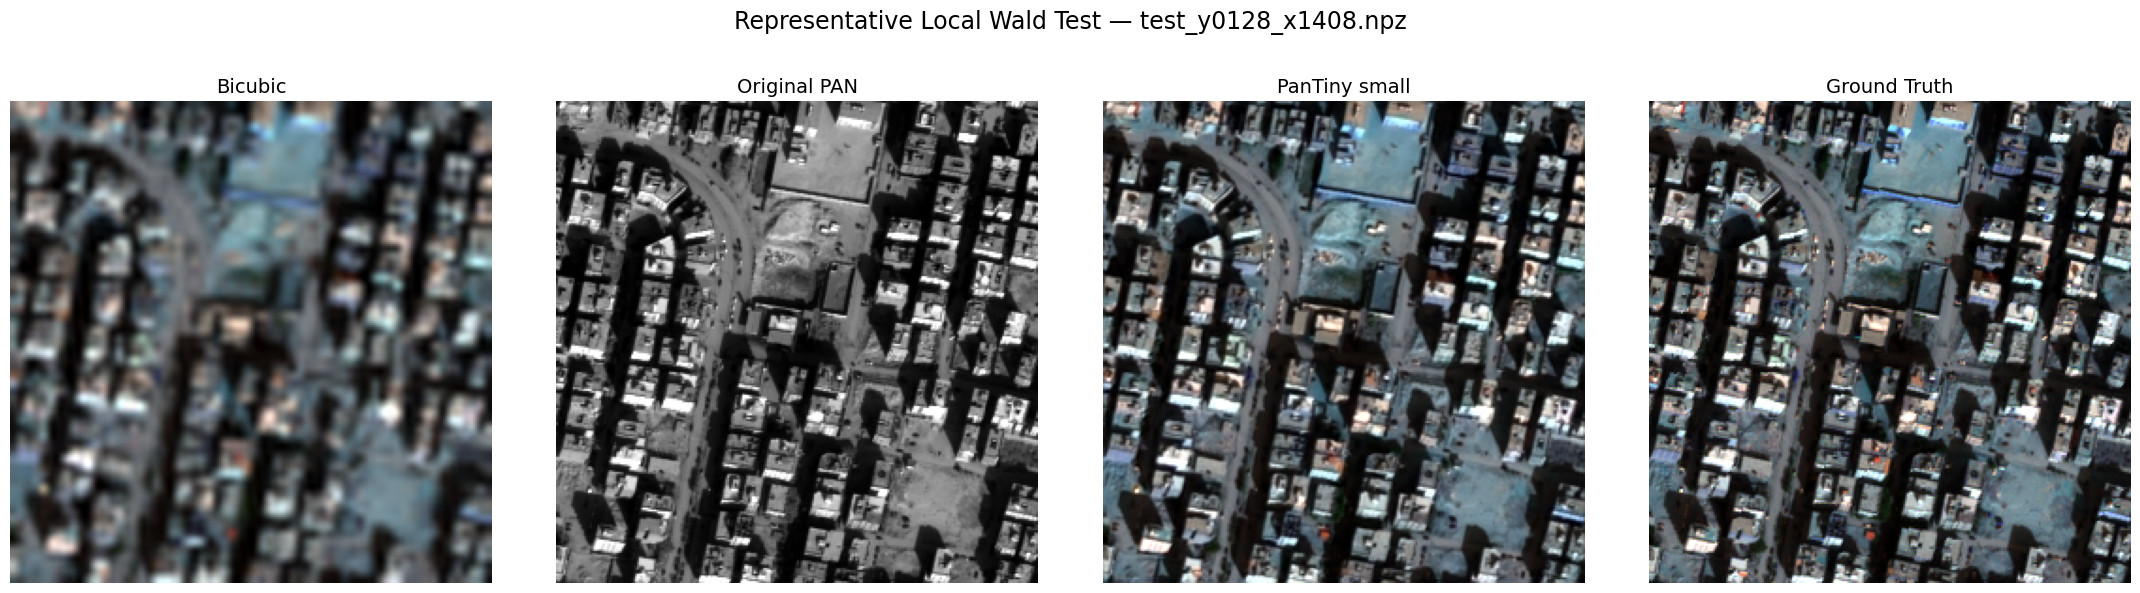

Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/PanTiny_6Band_Results/pantiny_small_representative_comparison.png


In [21]:

# Verify this order against the actual local sensor band metadata.
RGB_ZERO_BASED = [2, 1, 0]


def shared_rgb_limits(
    reference_chw: np.ndarray,
):
    lows = []
    highs = []

    for band_index in range(3):
        values = reference_chw[
            band_index
        ]

        finite = values[
            np.isfinite(values)
        ]

        low, high = np.percentile(
            finite,
            [1, 99],
        )

        lows.append(low)
        highs.append(high)

    return (
        np.asarray(
            lows,
            dtype=np.float32,
        )[:, None, None],
        np.asarray(
            highs,
            dtype=np.float32,
        )[:, None, None],
    )


def apply_rgb_limits(
    array_chw: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
):
    stretched = np.clip(
        (
            array_chw - low
        )
        / np.maximum(
            high - low,
            1e-6,
        ),
        0,
        1,
    )

    return np.moveaxis(
        stretched,
        0,
        -1,
    )


target_rgb_chw = visual_target[
    RGB_ZERO_BASED
]

bicubic_rgb_chw = visual_bicubic[
    RGB_ZERO_BASED
]

prediction_rgb_chw = visual_prediction[
    RGB_ZERO_BASED
]

display_low, display_high = shared_rgb_limits(
    target_rgb_chw
)

target_rgb = apply_rgb_limits(
    target_rgb_chw,
    display_low,
    display_high,
)

bicubic_rgb = apply_rgb_limits(
    bicubic_rgb_chw,
    display_low,
    display_high,
)

prediction_rgb = apply_rgb_limits(
    prediction_rgb_chw,
    display_low,
    display_high,
)

pan_low, pan_high = np.percentile(
    visual_pan[
        np.isfinite(visual_pan)
    ],
    [1, 99],
)

pan_display = np.clip(
    (
        visual_pan - pan_low
    )
    / max(
        float(pan_high - pan_low),
        1e-6,
    ),
    0,
    1,
)

figure = plt.figure(
    figsize=(22, 6)
)

panels = [
    ("Bicubic", bicubic_rgb, None),
    ("Original PAN", pan_display, "gray"),
    (
        f"PanTiny {MODEL_SIZE}",
        prediction_rgb,
        None,
    ),
    ("Ground Truth", target_rgb, None),
]

for panel_index, (
    title,
    image,
    cmap,
) in enumerate(
    panels,
    start=1,
):
    axis = figure.add_subplot(
        1,
        4,
        panel_index,
    )

    axis.imshow(
        image,
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    axis.set_title(
        title,
        fontsize=14,
    )

    axis.axis("off")

figure.suptitle(
    (
        "Representative Local Wald Test — "
        f"{representative_file}"
    ),
    fontsize=17,
)

figure.tight_layout(
    rect=[0, 0, 1, 0.92]
)

visual_path = (
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_representative_comparison.png"
)

figure.savefig(
    visual_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print("Saved:", visual_path)



# 15. Final Decision

PanTiny تستحق الانتقال إلى Full-Resolution inference إذا حققت واحدًا أوأكثر من الآتي:

1. PSNR أعلى أو قريبة جدًا من HAT.
2. SAM وERGAS لا يتدهوران بوضوح.
3. جودة بصرية قوية مع Parameter count أقل كثيرًا.
4. سرعة تدريب وInference أفضل بوضوح.
5. Per-image results مستقرة وليست معتمدة على عينات قليلة.


In [22]:

decision = {
    "model": f"PanTiny {MODEL_SIZE} 6-Band",
    "parameter_count": int(parameter_count),
    "test_images": int(len(test_df)),
    "PanTiny_PSNR": float(
        pantiny_summary["PSNR_mean"]
    ),
    "HAT_PSNR": 25.357463,
    "PSNR_difference": float(
        pantiny_summary["PSNR_mean"]
        - 25.357463
    ),
    "PanTiny_SSIM_global": float(
        pantiny_summary[
            "SSIM_global_mean"
        ]
    ),
    "PanTiny_SAM": float(
        pantiny_summary["SAM_mean"]
    ),
    "PanTiny_ERGAS": float(
        pantiny_summary["ERGAS_mean"]
    ),
    "PanTiny_L1": float(
        pantiny_summary["L1_mean"]
    ),
    "best_epoch": int(
        best_checkpoint["epoch"]
    ),
    "loss_mode": LOSS_MODE,
}

with open(
    RESULTS_DIR
    / f"pantiny_{MODEL_SIZE}_decision_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        decision,
        file,
        indent=2,
    )

print(
    json.dumps(
        decision,
        indent=2,
    )
)


{
  "model": "PanTiny small 6-Band",
  "parameter_count": 53034,
  "test_images": 22,
  "PanTiny_PSNR": 25.658881187438965,
  "HAT_PSNR": 25.357463,
  "PSNR_difference": 0.30141818743896565,
  "PanTiny_SSIM_global": 0.9777765246954832,
  "PanTiny_SAM": 1.8958474451845342,
  "PanTiny_ERGAS": 2.1034278815442864,
  "PanTiny_L1": 0.033077106811106205,
  "best_epoch": 42,
  "loss_mode": "paper_composite"
}



# Output Files

```text
PanTiny_6Band_Results/
├── best_pantiny_small_6band.pth
├── latest_pantiny_small_6band.pth
├── pantiny_small_training_history.csv
├── pantiny_small_training_curve.png
├── pantiny_small_local_test_per_image.csv
├── pantiny_small_local_test_summary.csv
├── pantiny_small_vs_existing_models.csv
├── pantiny_small_representative_comparison.png
├── pantiny_small_decision_summary.json
└── test_predictions_small/
```

بعد انتهاء التشغيل، أرسل:

```text
pantiny_small_local_test_summary.csv
pantiny_small_vs_existing_models.csv
```
